In [1]:
import numpy as np
import pandas as pd
import mne
import os
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

# For deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Loading Data

In [2]:
BASE_DIR = Path().resolve().parent  # wherever the notebook lives
FEATURE_PATH = BASE_DIR / "data" / "features"

In [3]:
def load_data(data_root = FEATURE_PATH) -> dict:
    data_root = Path(data_root)
    
    data = {
        "headband": {"features": [], "spectrograms": [], "subject_ids": []},
        "psg":      {"features": [], "spectrograms": [], "subject_ids": []},
    }

    subject_dirs = sorted([d for d in data_root.iterdir() if d.is_dir() and d.name.startswith("sub-")])

    for subject_dir in subject_dirs:
        subject_id = subject_dir.name

        for device in ["headband", "psg"]:
            device_dir = subject_dir / device
            if not device_dir.exists():
                print(f"Warning: {subject_id}/{device} not found, skipping.")
                continue

            # Load parquet
            parquet_files = list(device_dir.glob("*.parquet"))
            npy_files = list(device_dir.glob("*.npy"))

            if not parquet_files or not npy_files:
                print(f"Warning: Missing files in {subject_id}/{device}, skipping.")
                continue

            df = pd.read_parquet(parquet_files[0], engine="pyarrow")
            df["subject_id"] = subject_id  # track which subject each row belongs to

            spectrogram = np.load(npy_files[0])

            data[device]["features"].append(df)
            data[device]["spectrograms"].append(spectrogram)
            data[device]["subject_ids"].append(subject_id)

    # Concatenate everything
    for device in ["headband", "psg"]:
        data[device]["features"]     = pd.concat(data[device]["features"], ignore_index=True)
        data[device]["spectrograms"] = data[device]["spectrograms"]

    return data


if __name__ == "__main__":
    data = load_data(FEATURE_PATH)

    for device in ["headband", "psg"]:
        print(f"\n{device.upper()}")
        print(f"  Features shape:     {data[device]['features'].shape}")
        print(f"  Spectrograms: {len(data[device]['spectrograms'])} subjects, first shape: {data[device]['spectrograms'][0].shape}")
        print(f"  Subjects loaded:    {len(data[device]['subject_ids'])}")


HEADBAND
  Features shape:     (52381, 12)
  Spectrograms: 56 subjects, first shape: (996, 2, 30, 117)
  Subjects loaded:    56

PSG
  Features shape:     (52381, 20)
  Spectrograms: 56 subjects, first shape: (996, 6, 30, 117)
  Subjects loaded:    56


## Train/test Split

In [4]:
# Train/test split
def split_data(data, test_size=0.2, random_state=42):
    splits = {}

    for device in ["headband", "psg"]:
        subjects = data[device]["subject_ids"]
        
        train_subjects, test_subjects = train_test_split(
            subjects, test_size=test_size, random_state=random_state
        )

        train_subjects = set(train_subjects)
        test_subjects  = set(test_subjects)

        df      = data[device]["features"]
        specs   = data[device]["spectrograms"]
        sub_ids = data[device]["subject_ids"]

        # Split features by subject
        train_mask = df["subject_id"].isin(train_subjects)
        test_mask  = df["subject_id"].isin(test_subjects)

        # Split spectrograms by subject (preserving order within each subject)
        train_idx = [i for i, s in enumerate(sub_ids) if s in train_subjects]
        test_idx  = [i for i, s in enumerate(sub_ids) if s in test_subjects]

        splits[device] = {
            "train": {
                "features":    df[train_mask].reset_index(drop=True),
                "spectrograms": [specs[i] for i in train_idx],
                "subject_ids": [sub_ids[i] for i in train_idx],
            },
            "test": {
                "features":    df[test_mask].reset_index(drop=True),
                "spectrograms": [specs[i] for i in test_idx],
                "subject_ids": [sub_ids[i] for i in test_idx],
            }
        }

    return splits


splits = split_data(data)

# Verify
for device in ["headband", "psg"]:
    train_subs = splits[device]["train"]["subject_ids"]
    test_subs  = splits[device]["test"]["subject_ids"]
    print(f"\n{device.upper()}")
    print(f"  Train subjects: {len(train_subs)}")
    print(f"  Test subjects:  {len(test_subs)}")
    print(f"  Train epochs:   {len(splits[device]['train']['features'])}")
    print(f"  Test epochs:    {len(splits[device]['test']['features'])}")
    print(f"  Subject overlap (should be empty): {set(train_subs) & set(test_subs)}")


HEADBAND
  Train subjects: 44
  Test subjects:  12
  Train epochs:   41235
  Test epochs:    11146
  Subject overlap (should be empty): set()

PSG
  Train subjects: 44
  Test subjects:  12
  Train epochs:   41235
  Test epochs:    11146
  Subject overlap (should be empty): set()


In [5]:
df = splits["headband"]["train"]["features"]
nan_cols = df.isna().sum()
print(nan_cols[nan_cols > 0])

bp_delta    3
bp_theta    3
bp_alpha    3
bp_sigma    3
bp_beta     3
dtype: int64


## Approaches 1 & 2 (Linear and Tree-based Models)

In [8]:
# Feature columns
META_COLS = ["subject_id", "acq", "epoch_idx", "onset", "duration", "stage_hum"]

def get_features_labels(split, device, fold="train"):
    df = split[device][fold]["features"]
    df = df.dropna() # safe to just drop them
    X = df.drop(columns=META_COLS, errors="ignore")
    X = X.select_dtypes(include="number").values
    y = df["stage_hum"].values
    return X, y

# Models
def get_model(name):
    models = {
        "logistic_regression": LogisticRegression(
            solver="lbfgs",
            max_iter=1000,
            random_state=42,
        ),
        "linear_svm_ovr": OneVsRestClassifier(
            LinearSVC(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            )
        ),
        "random_forest": RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,  # uses all CPU cores
        )
    }
    if name not in models:
        raise ValueError(f"Unknown model: {name}. Available: {list(models.keys())}")
    return models[name]

# Pipeline (scaler & model)
def build_pipeline(model_name):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model",  get_model(model_name)),
    ])

# Train & Evaluate
def train_and_evaluate(splits, device, model_name):
    print(f"\n{'='*50}")
    print(f"  {device.upper()} — {model_name}")
    print(f"{'='*50}")

    X_train, y_train = get_features_labels(splits, device, "train")
    X_test,  y_test  = get_features_labels(splits, device, "test")

    print(f"  Train: {X_train.shape}, Test: {X_test.shape}")

    pipeline = build_pipeline(model_name)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{device.upper()} — {model_name} confusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return pipeline, y_pred, y_test


  HEADBAND — random_forest
  Train: (41232, 5), Test: (11146, 5)

  Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.71      0.60      1717
           1       0.21      0.03      0.05       559
           2       0.78      0.81      0.79      6793
           3       0.54      0.22      0.31       410
           4       0.34      0.31      0.33      1667

    accuracy                           0.66     11146
   macro avg       0.48      0.41      0.42     11146
weighted avg       0.63      0.66      0.64     11146



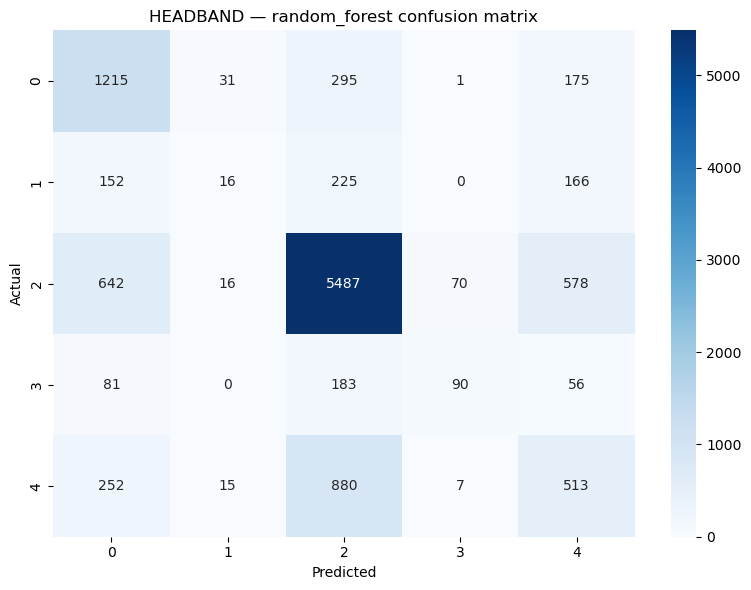


  PSG — random_forest
  Train: (41232, 11), Test: (11146, 11)

  Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.83      0.76      1717
           1       0.29      0.02      0.03       559
           2       0.78      0.91      0.84      6793
           3       0.67      0.35      0.46       410
           4       0.52      0.32      0.40      1667

    accuracy                           0.74     11146
   macro avg       0.60      0.49      0.50     11146
weighted avg       0.70      0.74      0.71     11146



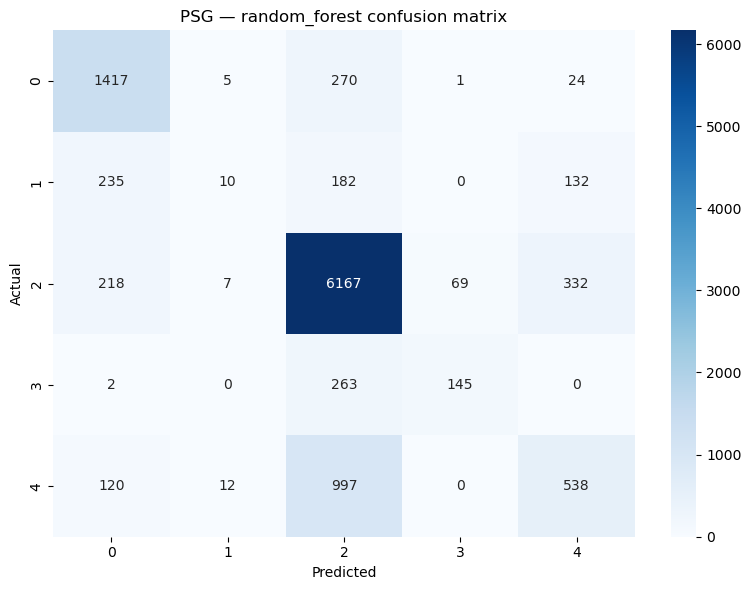

In [9]:
results = {}
for device in ["headband", "psg"]:
    pipeline, y_pred, y_test = train_and_evaluate(splits, device, "random_forest")
    results[device] = {"pipeline": pipeline, "y_pred": y_pred, "y_test": y_test}

## Approach 3: Fusion Deep Learning Model

In [23]:
def get_fusion_data(splits, fold="train"):
    df_hb = splits["headband"][fold]["features"].reset_index(drop=True)
    df_psg = splits["psg"][fold]["features"].reset_index(drop=True)

    specs_list = splits["headband"][fold]["spectrograms"]
    X_specs_all = np.concatenate(specs_list, axis=0)
    if X_specs_all.ndim == 3:
        X_specs_all = X_specs_all[..., np.newaxis]

    # Drop NaN rows from PSG
    df_psg = df_psg.dropna(subset=[c for c in df_psg.columns if c not in META_COLS])

    # Find matching headband rows by epoch identity
    join_keys = ["subject_id", "epoch_idx"]
    df_hb_indexed = df_hb[join_keys].copy()
    df_hb_indexed["hb_row"] = df_hb_indexed.index

    merged = df_psg[join_keys].merge(df_hb_indexed, on=join_keys, how="inner")

    # Use matched headband row positions to index spectrograms
    hb_rows = merged["hb_row"].values
    X_specs = X_specs_all[hb_rows]

    # PPG features from PSG
    X_ppg = df_psg.loc[merged.index].drop(columns=META_COLS, errors="ignore")
    X_ppg = X_ppg.select_dtypes(include="number").values

    y = df_psg.loc[merged.index]["stage_hum"].values

    print(f"Aligned epochs: {X_specs.shape[0]}, PPG: {X_ppg.shape[0]}, y: {y.shape[0]}")
    return X_specs, X_ppg, y

In [24]:
# Build fusion model: 2D CNN for EEG spectrograms + MLP for PPG features
def build_fusion_model(specs_shape, ppg_shape, num_classes):
    # EEG branch: 2D CNN
    eeg_input = keras.Input(shape=specs_shape, name="eeg_input")
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(eeg_input)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    eeg_output = layers.Dense(64, activation="relu")(x)
    
    # PPG branch: MLP
    ppg_input = keras.Input(shape=ppg_shape, name="ppg_input")
    y = layers.Dense(128, activation="relu")(ppg_input)
    y = layers.Dropout(0.5)(y)
    y = layers.Dense(64, activation="relu")(y)
    y = layers.Dropout(0.5)(y)
    ppg_output = layers.Dense(64, activation="relu")(y)
    
    # Fusion
    combined = layers.concatenate([eeg_output, ppg_output])
    z = layers.Dense(128, activation="relu")(combined)
    z = layers.Dropout(0.5)(z)
    z = layers.Dense(64, activation="relu")(z)
    z = layers.Dropout(0.5)(z)
    output = layers.Dense(num_classes, activation="softmax")(z)
    
    model = keras.Model(inputs=[eeg_input, ppg_input], outputs=output)
    return model

In [25]:
# Train and evaluate fusion model
def train_and_evaluate_fusion(splits):
    print(f"\n{'='*50}")
    print("  FUSION MODEL: EEG CNN + PPG MLP")
    print(f"{'='*50}")
    
    X_specs_train, X_ppg_train, y_train = get_fusion_data(splits, "train")
    X_specs_test, X_ppg_test, y_test = get_fusion_data(splits, "test")
    
    print(f"  Train specs: {X_specs_train.shape}, PPG: {X_ppg_train.shape}")
    print(f"  Test specs: {X_specs_test.shape}, PPG: {X_ppg_test.shape}")
    
    # Encode labels
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)
    num_classes = len(le.classes_)
    print(f"  Classes: {le.classes_}")
    
    # Build model
    specs_shape = X_specs_train.shape[1:]  # (freq, time, 1)
    ppg_shape = (X_ppg_train.shape[1],)    # (n_features,)
    model = build_fusion_model(specs_shape, ppg_shape, num_classes)
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    # Train
    history = model.fit(
        [X_specs_train, X_ppg_train], y_train_enc,
        validation_data=([X_specs_test, X_ppg_test], y_test_enc),
        epochs=20,
        batch_size=32,
        verbose=1
    )
    
    # Evaluate
    y_pred_prob = model.predict([X_specs_test, X_ppg_test])
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    print(f"\n  Classification Report:")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))
    
    # Confusion matrix
    cm = confusion_matrix(y_test_enc, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title("Fusion Model Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    return model, y_pred, y_test_enc, le

In [26]:
print(splits["headband"]["train"]["features"].columns.tolist())
print(splits["psg"]["train"]["features"].columns.tolist())

['subject', 'acq', 'epoch_idx', 'onset', 'duration', 'stage_hum', 'bp_delta', 'bp_theta', 'bp_alpha', 'bp_sigma', 'bp_beta', 'subject_id']
['subject', 'acq', 'epoch_idx', 'onset', 'duration', 'stage_hum', 'eeg_bp_delta', 'eeg_bp_theta', 'eeg_bp_alpha', 'eeg_bp_sigma', 'eeg_bp_beta', 'ppg_bad_epoch', 'ppg_bad_reason', 'ppg_RMSSD', 'ppg_SDNN', 'ppg_HR_mean_bpm', 'ppg_n_beats', 'ppg_pulse_amp_mean', 'ppg_pulse_amp_std', 'subject_id']


In [27]:
# Run fusion model
fusion_model, y_pred_fusion, y_test_fusion, le = train_and_evaluate_fusion(splits)


  FUSION MODEL: EEG CNN + PPG MLP


IndexError: index 41232 is out of bounds for axis 0 with size 41232